In [376]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm

# Stochastic Simulation

## Exercise 1

## 1.1

### (a)

In [377]:
# Implementation of linear congruential generator
def LCG(x0, a, c, M, iter): 
    """
    Generate random numbers using a linear congrential generator
    Input: 
        x0: Initial value 
        a: Multiplier 
        c: Increment 
        M: Modulus 
        Iter: How many number iterations

    Output: A list of random number of length iter + 1.      
    """
            
    x = x0 
    Numbers = [x/M]
    for i in range(iter):
        x = (a*x + c) % M 
        U = x/M
        Numbers.append(U)
    return Numbers

In [378]:
# Test 1, values as of slides to check if function works correctly
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 16
LCG(x0, a, c, M, iter)

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875]

In [379]:
# # Test 2, BAD random numbers 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 10000 
RN = LCG(x0, a, c, M, iter)
RN

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 

(array([1250.,  625., 1251.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([0.     , 0.09375, 0.1875 , 0.28125, 0.375  , 0.46875, 0.5625 ,
        0.65625, 0.75   , 0.84375, 0.9375 ]),
 <BarContainer object of 10 artists>)

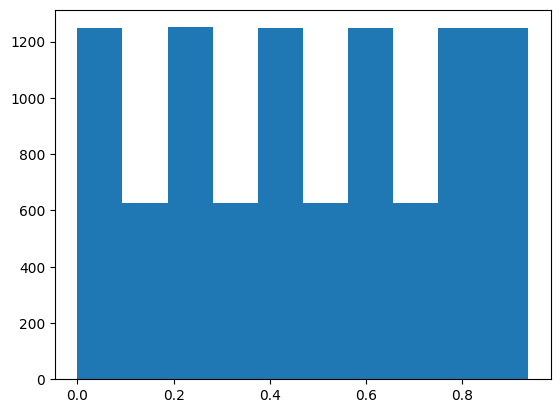

In [ ]:
# Histogram plot with 10 bins 

plt.hist(RN,10)

### (b)

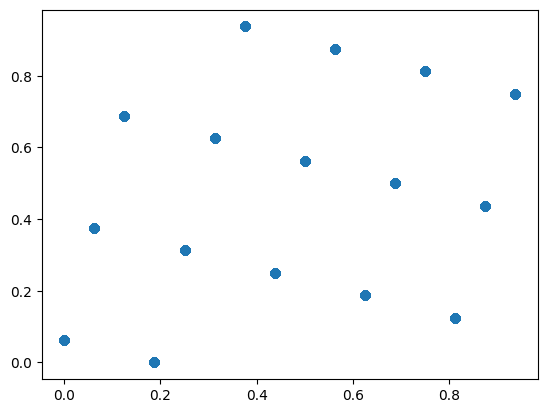

In [381]:
# Scatterplot 

plt.scatter(RN[:-1], RN[1:])

In [ ]:
# Defien function to do a Chi-squared test 

def T_chi_square(n_observed, n_expected, m): 
    """
    Do a chi_square test
    Input: 
        n_observed: Array with the number of observed numbers at each bin 
        n_expected: The expected number of numbers at each bin given the expected distribution 
        m: The number of estimated parameters 
    
    Output: The p_value for hypothesis test 
    """
    
    # Number of classes 
    n_classes = len(n_observed)

    # Compute the test statistic 
    T = np.sum((n_observed - n_expected)**2/n_expected)


    # Degrees of freedom
    df = n_classes - 1 - m

    # Compute p-value 
    p_value = chi2.sf(T,df)
    return p_value

In [ ]:
# Chi-squared test with 10 bins

bins = 10
N = len(RN)
n_observed,_ = np.histogram(RN, bins)
n_expected = np.ones(bins) * (N/bins) #Uniform distribution
m = 0 

T_chi_square(n_observed, n_expected, m) #Small p-value, very unlikely that derivation so large if the data followed a uniform distribution 

np.float64(4.193876173735931e-196)

In [ ]:
def ecdf(x,obs): 
    """
    Compute the expected distrubution
    Input: 
    """

    obs = np.array(obs)

    ecdf = np.sum(obs <= x)/len(obs)
    return ecdf

def uniform_cdf(x, a=0, b=1):
    if x < a:
        return 0.0
    elif x > b:
        return 1.0
    else:
        return (x - a) / (b - a)

def Kolmogorov_Smirnov(obs,m): 
    x = np.linspace(0,1,m)
    F_n = []
    F = []
    for val in x:
        F_n.append(ecdf(val, obs))
        F.append(uniform_cdf(val))
    D_n = np.max(abs(np.array(F_n)- np.array(F)))

    return D_n


In [385]:
m = 100
D_n = Kolmogorov_Smirnov(RN, m)
D_n

np.float64(0.062493750624937505)

In [386]:
# Adjusted test statistic 

n = len(RN)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n # Not good result see 16 

np.float64(6.257255513199329)

In [387]:
# Wald-Wolfowitz run test

def Wald_Wolfowitz(obs):
    median = np.median(obs)
    above_below = []
    for x in obs:
        if x > median:
            above_below.append(1)
        if x <= median: 
            above_below.append(0)
    
    n1 = np.sum(above_below)
    n2 = len(above_below) - n1 
    runs = 1 
    for i in range(1,len(above_below)):
        if above_below[i] != above_below[i-1]:
            runs += 1
    
    T = runs 
 

    mean = 2*n1*n2/(n1 + n2) +1 
    var = 2*(n1*n2*(2*n1*n2 -n1 - n2)/( (n1+n2)**2*(n1 + n2 -1)))
    z = (T - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values
    


In [388]:
# run test 1
Wald_Wolfowitz(RN)

np.float64(4.759054458520932e-138)

In [389]:
def knuth(obs):
    obs = np.array(obs)
    n = len(obs)

    # --- Step 1: compute increasing runs ---
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    

    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    

In [390]:
knuth(RN)

np.float64(1.4733787998841428e-238)

In [391]:
def correlation_coef(obs,h):
    obs = np.array(RN)
    n= len(obs)
    c = np.sum(obs[:-h] * obs[h:]) / (n - h)

    mean = 0.25
    var = 7/(144*n)
    z = (c - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values

In [392]:
correlation_coef(RN,1)

np.float64(0.00039471242218985114)

In [393]:
correlation_coef(RN,3)

np.float64(1.1720063046768725e-135)

### (c)

In [394]:
""" 
# GOOD example 
x0 = 3 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)
"""

' \n# GOOD example \nx0 = 3 \nM = 2**32 \na = 1203515245\nc = 12345\niter = 10000 \nRN = LCG(x0, a, c, M, iter)\n'

## 1.2 

In [395]:
RN_sys = np.random.rand(10000)


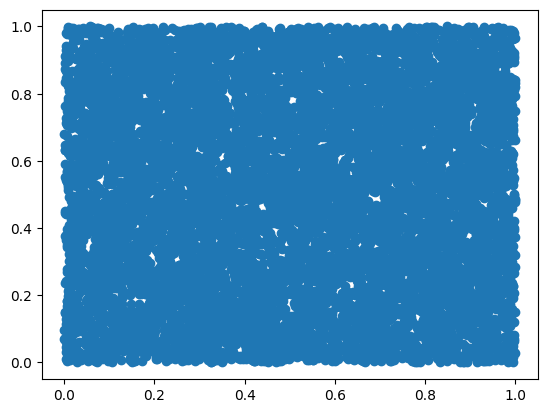

In [396]:
# Scatterplot 

plt.scatter(RN_sys[:-1], RN_sys[1:])

In [397]:
# Chi_square
bins = 10
N = len(RN_sys)
n_observed,_ = np.histogram(RN_sys, bins)
n_expected = np.ones(bins) * (N/bins)
m = 0 

T_chi_square(n_observed, n_expected, m)

np.float64(0.5087658142758753)

In [398]:
# Kolmogorov_Smirnov
m = 100
D_n = Kolmogorov_Smirnov(RN_sys, m)
D_n

# Adjusted test statistic 

n = len(RN_sys)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n 

np.float64(0.9680395648484917)

In [399]:
# Run test 1
Wald_Wolfowitz(RN_sys)

np.float64(0.11408877267991803)

In [400]:
# Run test 1

knuth(RN_sys)

np.float64(0.4022869086466004)

In [401]:
correlation_coef(RN_sys,1), correlation_coef(RN_sys,3)

(np.float64(0.00039471242218985114), np.float64(1.1720063046768725e-135))